# Peak Demand Prediction

## 1. Load and check the forecast files

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, os

files = [
    "final_dl_predictions.csv",
    "lstm_predictions.csv",
    "gru_predictions.csv",
    "xgboost_test_predictions.csv",
    "classical_timeseries_predictions.csv",
]
for f in files:
    print("=" * 70)
    try:
        d = pd.read_csv(os.path.join("..", "reports", f))
        print(f, d.shape)
        print(d.columns.tolist())
        print(d.head(3).to_string())
    except Exception as e:
        print(f, "-> error:", e)

final_dl_predictions.csv (307058, 4)
['Datetime', 'Actual', 'Predicted', 'Residual']
              Datetime  Actual  Predicted  Residual
0  2010-04-18 18:06:00   1.044   1.101878 -0.057878
1  2010-04-18 18:07:00   0.480   1.003121 -0.523121
2  2010-04-18 18:08:00   0.312   0.419276 -0.107276
lstm_predictions.csv (307058, 2)
['Actual', 'Predicted']
     Actual  Predicted
0  0.087634   0.094563
1  0.036574   0.088835
2  0.021365   0.040288
gru_predictions.csv (307058, 2)
['Actual', 'Predicted']
     Actual  Predicted
0  0.087634   0.086653
1  0.036574   0.084691
2  0.021365   0.035760
xgboost_test_predictions.csv (307117, 4)
['Datetime', 'Actual', 'Predicted', 'Residual']
              Datetime  Actual  Predicted  Residual
0  2010-04-18 17:07:00   0.342   0.340738  0.001262
1  2010-04-18 17:08:00   0.340   0.337095  0.002905
2  2010-04-18 17:09:00   0.340   0.337728  0.002272
classical_timeseries_predictions.csv (5122, 3)
['Datetime', 'actual', 'arima_pred']
              Datetime    act

### Model selection metrics from Groups 3 and 4

In [2]:
for f in ["final_dl_selection.csv", "final_dl_vs_xgboost.csv", "final_dl_metrics.csv"]:
    print("=" * 70); print(f)
    try:
        print(pd.read_csv(os.path.join("..", "reports", f)).to_string())
    except Exception as e:
        print("error:", e)

final_dl_selection.csv
  Selected_Model Architecture  Units  Dropout  Window_Size  Batch_Size Optimizer  Epochs       MAE      RMSE   MAPE        R2
0     Tuned LSTM         LSTM    128      0.3           60          64      Adam       3  0.007717  0.018971  13.91  0.940856
final_dl_vs_xgboost.csv
              Model         Model_Type       MAE      RMSE       MAPE        R2
0  Final Tuned LSTM      Deep Learning  0.086464  0.207164  11.851874  0.942195
1           XGBoost  Non-Deep Learning  0.015710  0.028450   2.360000  0.998910
final_dl_metrics.csv
              Model       MAE      RMSE       MAPE        R2  Window_Size  Batch_Size  Units  Dropout
0  Final Tuned LSTM  0.086464  0.207164  11.851874  0.942195           60          64    128      0.3


## 2. Historical peak analysis
Hourly means of Actual and Predicted (Group 4 file), then the highest hours, percentile candidates for the threshold, and the daily peak value and hour.

In [3]:
p = pd.read_csv("../reports/final_dl_predictions.csv", parse_dates=["Datetime"])
p = p.set_index("Datetime").sort_index()

hourly = p[["Actual", "Predicted"]].resample("1h").mean().dropna()
hourly["hour"] = hourly.index.hour
hourly["weekday"] = hourly.index.day_name()
hourly["weekend"] = hourly.index.dayofweek >= 5
hourly["month"] = hourly.index.month

print("hours:", len(hourly), "|", hourly.index.min(), "->", hourly.index.max())
hourly[["Actual", "Predicted"]].describe()

hours: 5120 | 2010-04-18 18:00:00 -> 2010-11-26 21:00:00


,Actual,Predicted
count,5120.000000,5120.000000
mean,0.958171,0.970683
std,0.709710,0.693881
min,0.195100,0.217241
25%,0.361592,0.383056
50%,0.705633,0.722489
75%,1.431975,1.444812
max,5.626833,5.466652


,Actual_kW,Predicted_kW
Datetime,,
2010-11-20 18:00:00,5.627,5.467
2010-11-04 20:00:00,4.463,3.988
2010-11-04 08:00:00,4.419,4.218
2010-11-14 15:00:00,4.157,3.789
2010-10-14 19:00:00,4.118,3.991
2010-11-04 19:00:00,4.054,3.922
2010-06-23 21:00:00,3.941,3.722
2010-10-02 20:00:00,3.940,3.669
2010-10-10 21:00:00,3.901,3.851


Actual percentiles (kW):
  80th: 1.547
  90th: 1.931
  95th: 2.330
  99th: 3.128

Days used: 213 | mean daily peak (kW): 2.362


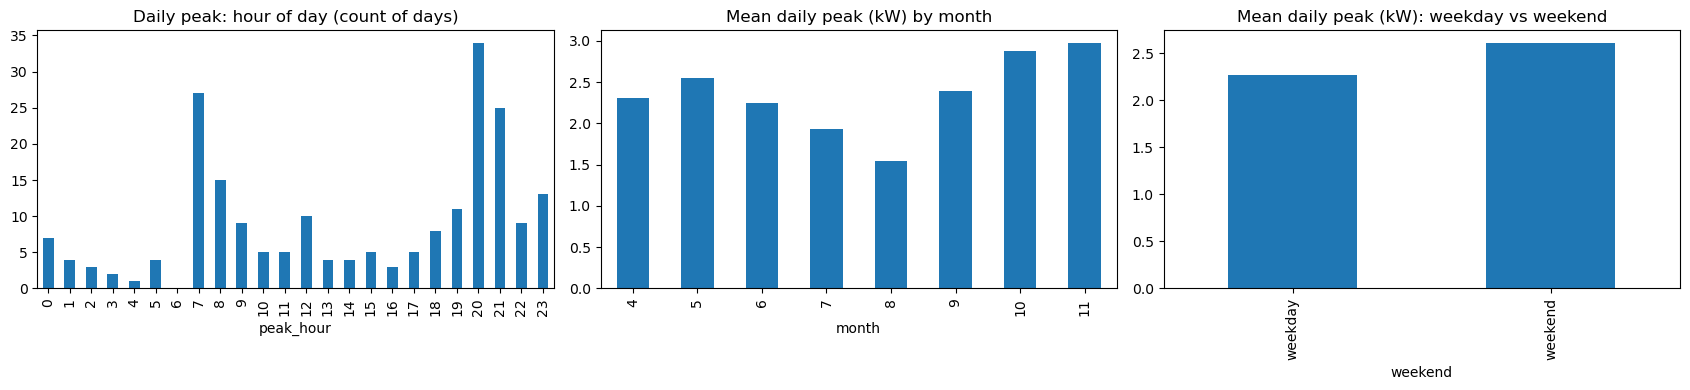

In [4]:
# 1) Highest 15 hours
top = hourly["Actual"].nlargest(15).to_frame("Actual_kW")
top["Predicted_kW"] = hourly.loc[top.index, "Predicted"]
display(top.round(3))

# 2) Percentiles (peak threshold candidates)
print("Actual percentiles (kW):")
for q in [0.80, 0.90, 0.95, 0.99]:
    print(f"  {int(q*100)}th: {hourly['Actual'].quantile(q):.3f}")

# 3) Daily peak value and hour (only days with 20+ hours of data)
g = hourly.groupby(hourly.index.date)
daily = pd.DataFrame({
    "peak_kw": g["Actual"].max(),
    "peak_hour": g["Actual"].idxmax().map(lambda t: t.hour),
    "n_hours": g["Actual"].size(),
})
daily = daily[daily["n_hours"] >= 20]
daily.index = pd.to_datetime(daily.index)
daily["weekend"] = daily.index.dayofweek >= 5
daily["month"] = daily.index.month
print("\nDays used:", len(daily), "| mean daily peak (kW):", round(daily["peak_kw"].mean(), 3))

# 4) When do daily peaks happen?
fig, ax = plt.subplots(1, 3, figsize=(17, 4))
daily["peak_hour"].value_counts().reindex(range(24), fill_value=0).plot.bar(ax=ax[0], title="Daily peak: hour of day (count of days)")
daily.groupby("month")["peak_kw"].mean().plot.bar(ax=ax[1], title="Mean daily peak (kW) by month")
daily.groupby("weekend")["peak_kw"].mean().rename({False: "weekday", True: "weekend"}).plot.bar(ax=ax[2], title="Mean daily peak (kW): weekday vs weekend")
plt.tight_layout(); plt.show()

## 3. Compare the three forecasts at hourly level
All three files are converted to hourly means and compared on the 5,120 common hours. ARIMA never forecasts above about 1.1 kW, so it cannot find peaks.

In [5]:
def load_min(fname):
    d = pd.read_csv(os.path.join("..", "reports", fname), parse_dates=["Datetime"])
    return d.set_index("Datetime").sort_index()[["Actual", "Predicted"]]

dl_h  = load_min("final_dl_predictions.csv").resample("1h").mean().dropna()
xgb_h = load_min("xgboost_test_predictions.csv").resample("1h").mean().dropna()

ar = pd.read_csv(os.path.join("..", "reports", "classical_timeseries_predictions.csv"), parse_dates=["Datetime"])
ar_h = ar.set_index("Datetime").sort_index()[["actual", "arima_pred"]].rename(
    columns={"actual": "Actual", "arima_pred": "Predicted"})

models = {"Tuned LSTM (G4)": dl_h, "XGBoost (G3)": xgb_h, "ARIMA (G3)": ar_h}
for n, d in models.items():
    print(n, len(d), d.index.min(), "->", d.index.max())

common = dl_h.index.intersection(xgb_h.index).intersection(ar_h.index)
print("common hours:", len(common))

# do all three files have the same Actual values?
act = pd.DataFrame({n: d.loc[common, "Actual"] for n, d in models.items()})
print("max difference in Actual between files (kW):", round((act.max(axis=1) - act.min(axis=1)).max(), 4))

# hourly accuracy on the common hours
from sklearn.metrics import mean_absolute_error, mean_squared_error
rows = []
for n, d in models.items():
    a, pr = d.loc[common, "Actual"], d.loc[common, "Predicted"]
    rows.append({"model": n, "MAE": mean_absolute_error(a, pr),
                 "RMSE": mean_squared_error(a, pr) ** 0.5,
                 "bias (Pred-Actual)": (pr - a).mean(), "max_pred": pr.max()})
pd.DataFrame(rows).round(4)

Tuned LSTM (G4) 5120 2010-04-18 18:00:00 -> 2010-11-26 21:00:00
XGBoost (G3) 5121 2010-04-18 17:00:00 -> 2010-11-26 21:00:00
ARIMA (G3) 5122 2010-04-18 16:00:00 -> 2010-11-26 21:00:00
common hours: 5120
max difference in Actual between files (kW): 0.0502


,model,MAE,RMSE,bias (Pred-Actual),max_pred
0,Tuned LSTM (G4),0.0238,0.0314,0.0125,5.4667
1,XGBoost (G3),0.0088,0.0141,-0.0004,5.6514
2,ARIMA (G3),0.5949,0.7165,0.0407,1.0898


### Can Group 3's XGBoost features be checked?
`src/regression_models.py` is empty in the repository, so the features are looked up in the reports and in the model file instead. The XGBoost accuracy is treated as unverified until Group 3 confirms which features it used.

In [6]:
txt = open("../src/regression_models.py", encoding="utf-8").read()
print("lines:", len(txt.splitlines()))
for i, line in enumerate(txt.splitlines(), 1):
    if any(k in line.lower() for k in ["feature", "drop", "lag", "target", "y =", "x ="]):
        print(i, line)

lines: 0


In [7]:
for f in ["member1_baseline_regression_report.md", "data_dictionary.md", "feature_engineering_report.md"]:
    path = os.path.join("..", "reports", f)
    print("=" * 70); print(f)
    if not os.path.exists(path):
        print("not found"); continue
    n = 0
    for i, line in enumerate(open(path, encoding="utf-8").read().splitlines(), 1):
        if any(k in line.lower() for k in ["xgboost", "feature", "leak", "lag", "target", "intensity", "sub_metering"]):
            print(i, line[:200]); n += 1
            if n >= 40: print("..."); break

# feature names stored inside the XGBoost model file (Group 3 repo file, needs xgboost installed)
try:
    import joblib
    m = joblib.load("../models/xgboost.pkl")
    names = getattr(m, "feature_names_in_", None)
    if names is None and hasattr(m, "get_booster"):
        names = m.get_booster().feature_names
    print("=" * 70); print("XGBoost features:", list(names) if names is not None else "not stored")
except Exception as e:
    print("model load error:", e)

member1_baseline_regression_report.md
data_dictionary.md
12 | `Global_active_power` | float64 | kilowatts (kW) | Primary prediction target; household global active power. |
15 | `Global_intensity` | float64 | amperes (A) | Minute-averaged household current intensity. |
16 | `Sub_metering_1` | float64 | watt-hours (Wh) | Energy sub-metering for kitchen appliances. |
17 | `Sub_metering_2` | float64 | watt-hours (Wh) | Energy sub-metering for laundry appliances. |
18 | `Sub_metering_3` | float64 | watt-hours (Wh) | Energy sub-metering for climate-control and water-heating appliances. |
22 Member 1 interpolated complete gaps of five minutes or less. The remaining 25,903 rows with missing measurement values are long gaps and remain missing in the final dataset. Timestamp rows are preserv
24 Zero measurements and genuine extreme peaks are retained. Statistical IQR outlier flags are screening information, not automatic deletion rules.
feature_engineering_report.md
2 ## Feature Engineering Mod

## 4. Peak definition and peak-hour detection
Peak hour = hourly mean at or above the 95th percentile of Actual (2.330 kW). Each forecast is judged on whether it flags the same hours (precision / recall / F1), using both the same threshold and the model's own 95th percentile, and on its error during the actual peak hours.

In [8]:
from sklearn.metrics import precision_score, recall_score, f1_score

ref = dl_h.loc[common, "Actual"]
pred = pd.DataFrame({n: d.loc[common, "Predicted"] for n, d in models.items()})

PEAK_Q = 0.95
thr = ref.quantile(PEAK_Q)
y_true = ref >= thr
print(f"peak threshold ({PEAK_Q:.0%} percentile of Actual): {thr:.3f} kW | actual peak hours: {int(y_true.sum())} of {len(ref)}")

rows = []
for n in pred.columns:
    for label, t in [("same threshold", thr), ("own 95th percentile", pred[n].quantile(PEAK_Q))]:
        yp = pred[n] >= t
        rows.append({"model": n, "rule": label, "threshold": round(t, 3), "flagged": int(yp.sum()),
                     "precision": precision_score(y_true, yp, zero_division=0),
                     "recall": recall_score(y_true, yp, zero_division=0),
                     "F1": f1_score(y_true, yp, zero_division=0)})
display(pd.DataFrame(rows).round(3))

# error on the real peak hours only
err = pred.sub(ref, axis=0)[y_true]
display(pd.DataFrame({
    "MAE on peak hours (kW)": err.abs().mean(),
    "RMSE on peak hours (kW)": (err ** 2).mean() ** 0.5,
    "bias on peak hours (kW)": err.mean(),
}).round(3))

peak threshold (95% percentile of Actual): 2.330 kW | actual peak hours: 256 of 5120


,model,rule,threshold,flagged,precision,recall,F1
0,Tuned LSTM (G4),same threshold,2.330,252,0.988,0.973,0.980
1,Tuned LSTM (G4),own 95th percentile,2.319,256,0.980,0.980,0.980
2,XGBoost (G3),same threshold,2.330,253,0.988,0.977,0.982
3,XGBoost (G3),own 95th percentile,2.321,256,0.984,0.984,0.984
4,ARIMA (G3),same threshold,2.330,0,0.000,0.000,0.000
5,ARIMA (G3),own 95th percentile,1.081,256,0.027,0.027,0.027


,MAE on peak hours (kW),RMSE on peak hours (kW),bias on peak hours (kW)
Tuned LSTM (G4),0.057,0.080,-0.051
XGBoost (G3),0.022,0.028,-0.003
ARIMA (G3),1.852,1.911,-1.852


### Daily peak value and time
For each day with at least 20 hours of data, the predicted daily peak (value and hour) is compared with the actual one: MAE, RMSE, and timing accuracy (exact hour, within 1 h, within 2 h).

In [9]:
days_n = ref.groupby(ref.index.date).size()
ok_days = pd.to_datetime(days_n[days_n >= 20].index)   # skip days with big gaps

def daily_peak(s):
    g = s.groupby(s.index.date)
    out = pd.DataFrame({"peak_kw": g.max(), "peak_time": g.idxmax()})
    out.index = pd.to_datetime(out.index)
    return out.loc[out.index.intersection(ok_days)]

act_d = daily_peak(ref)
rows = []
for n in pred.columns:
    pr_d = daily_peak(pred[n]).loc[act_d.index]
    e = pr_d["peak_kw"] - act_d["peak_kw"]
    dh = ((pr_d["peak_time"] - act_d["peak_time"]).dt.total_seconds() / 3600).abs()
    rows.append({"model": n, "days": len(act_d),
                 "peak MAE (kW)": e.abs().mean(), "peak RMSE (kW)": (e ** 2).mean() ** 0.5,
                 "peak bias (kW)": e.mean(),
                 "timing exact": (dh == 0).mean(),
                 "within 1h": (dh <= 1).mean(), "within 2h": (dh <= 2).mean()})
pd.DataFrame(rows).round(3)

,model,days,peak MAE (kW),peak RMSE (kW),peak bias (kW),timing exact,within 1h,within 2h
0,Tuned LSTM (G4),213,0.041,0.064,-0.030,0.944,0.953,0.958
1,XGBoost (G3),213,0.019,0.027,-0.003,0.981,0.986,0.995
2,ARIMA (G3),213,1.366,1.557,-1.363,0.033,0.052,0.066


### Group 2's `Peak` feature
For reference: how Group 2 defined `Peak` (minute-level, above the 75th percentile of `Global_active_power`). This notebook uses stricter, hourly definitions.

In [10]:
lines = open("../reports/feature_engineering_report.md", encoding="utf-8").read().splitlines()
print("\n".join(f"{i}: {l}" for i, l in enumerate(lines[9:50], start=10)))

10: data/processed/energy_clean.csv
11: ```
12: 
13: ### Features Created
14: 
15: #### Time-Based Features
16: - Datetime
17: - Hour
18: - Day
19: - Month
20: - DayOfWeek
21: - Week
22: - Quarter
23: - Weekend
24: 
25: #### Lag Features
26: - Lag_1
27: - Lag_24
28: - Lag_168
29: 
30: #### Rolling Features
31: - RollingMean_24
32: - RollingStd_24
33: 
34: #### Trend Features
35: - Difference
36: - PctChange
37: 
38: #### Peak Demand Feature
39: - Peak
40: 
41: ### Data Validation
42: - Checked for missing values
43: - Removed rows containing invalid values generated by lag and rolling calculations
44: - Verified all engineered features
45: 
46: ### Output Dataset
47: 
48: ```text
49: data/processed/feature_engineered_dataset.csv
50: ```


## 5. Forecast-based vs day-ahead approaches
Forecast-based approaches use the forecast for the same day. Day-ahead approaches use only earlier days. Hour distances are circular (23:00 and 00:00 are 1 hour apart).

In [11]:
hist = act_d.copy()                      # actual daily peaks (from the daily peak section)
hist["peak_hour"] = hist["peak_time"].dt.hour

def circ(a, b):                          # hour distance (23:00 and 00:00 = 1 hour apart)
    d = (a - b).abs()
    return np.minimum(d, 24 - d)

def evaluate(name, val_pred, hour_pred):
    ok = val_pred.notna() & hour_pred.notna()
    e = val_pred[ok] - hist.loc[ok, "peak_kw"]
    dh = circ(hour_pred[ok], hist.loc[ok, "peak_hour"])
    return {"approach": name, "days": int(ok.sum()),
            "peak MAE (kW)": e.abs().mean(), "peak RMSE (kW)": (e ** 2).mean() ** 0.5,
            "peak bias (kW)": e.mean(), "timing exact": (dh == 0).mean(),
            "within 1h": (dh <= 1).mean(), "within 2h": (dh <= 2).mean()}

rows = []
# A) forecast-based (one-step-ahead forecasts, hourly means)
for n in pred.columns:
    pr_d = daily_peak(pred[n]).loc[hist.index]
    rows.append(evaluate(f"{n} (forecast-based)", pr_d["peak_kw"], pr_d["peak_time"].dt.hour))

# B) history-based, uses only earlier days
rows.append(evaluate("Yesterday's peak", hist["peak_kw"].shift(1), hist["peak_hour"].shift(1)))

d7 = hist.index - pd.Timedelta(days=7)
rows.append(evaluate("Same day last week",
                     pd.Series(hist["peak_kw"].reindex(d7).values, index=hist.index),
                     pd.Series(hist["peak_hour"].reindex(d7).values, index=hist.index)))

val14 = hist["peak_kw"].shift(1).rolling(14, min_periods=7).mean()
hr14 = hist["peak_hour"].shift(1).rolling(14, min_periods=7).apply(lambda x: pd.Series(x).mode().iloc[0], raw=True)
rows.append(evaluate("Last 14 days (mean value, most common hour)", val14, hr14))

comparison = pd.DataFrame(rows)
comparison.round(3)

,approach,days,peak MAE (kW),peak RMSE (kW),peak bias (kW),timing exact,within 1h,within 2h
0,Tuned LSTM (G4) (forecast-based),213,0.041,0.064,-0.030,0.944,0.953,0.958
1,XGBoost (G3) (forecast-based),213,0.019,0.027,-0.003,0.981,0.986,0.995
2,ARIMA (G3) (forecast-based),213,1.366,1.557,-1.363,0.033,0.113,0.169
3,Yesterday's peak,212,0.572,0.778,-0.001,0.137,0.307,0.406
4,Same day last week,197,0.563,0.758,0.024,0.117,0.223,0.294
5,"Last 14 days (mean value, most common hour)",206,0.485,0.623,-0.020,0.146,0.291,0.359


### Where Group 2's `Peak` flag is created
Search of `04_feature_engineering.ipynb` for the peak definition.

In [12]:
import json
nb = json.load(open("04_feature_engineering.ipynb", encoding="utf-8"))
found = 0
for i, c in enumerate(nb["cells"]):
    s = "".join(c["source"])
    if c["cell_type"] == "code" and "peak" in s.lower():
        print(f"--- cell {i}"); print(s[:1500]); found += 1
print("cells mentioning peak:", found)

--- cell 17
threshold = df["Global_active_power"].quantile(0.75)

df["Peak"] = (
    df["Global_active_power"] > threshold
).astype(int)

cells mentioning peak: 1


## 6. Recurring peak patterns
Share of days by peak period (morning 06-09, evening 18-22, other), weekday vs weekend, and daily peak level by month.

Share of days by peak period:
peak_period
evening (18-22)    0.408
other              0.352
morning (06-09)    0.239
Name: proportion, dtype: float64

Top peak hours: {20: 34, 7: 27, 21: 25, 8: 15, 23: 13, 19: 11}


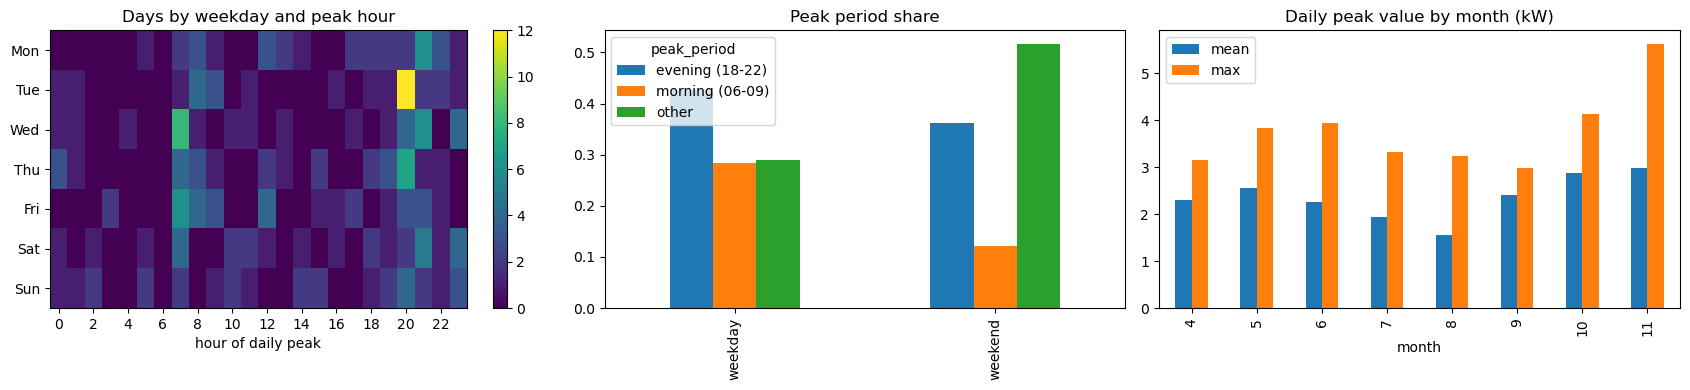

In [13]:
def period(hr):
    if 6 <= hr <= 9:   return "morning (06-09)"
    if 18 <= hr <= 22: return "evening (18-22)"
    return "other"

hist["peak_period"] = hist["peak_hour"].map(period)
hist["dow"] = hist.index.dayofweek
hist["weekend"] = hist["dow"] >= 5
hist["month"] = hist.index.month

print("Share of days by peak period:")
print(hist["peak_period"].value_counts(normalize=True).round(3))
print("\nTop peak hours:", hist["peak_hour"].value_counts().head(6).to_dict())

fig, ax = plt.subplots(1, 3, figsize=(17, 4))
ct = pd.crosstab(hist["dow"], hist["peak_hour"]).reindex(index=range(7), columns=range(24), fill_value=0)
im = ax[0].imshow(ct.values, aspect="auto", cmap="viridis")
ax[0].set_yticks(range(7)); ax[0].set_yticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
ax[0].set_xticks(range(0, 24, 2)); ax[0].set_xlabel("hour of daily peak")
ax[0].set_title("Days by weekday and peak hour"); plt.colorbar(im, ax=ax[0])

pd.crosstab(hist["weekend"], hist["peak_period"], normalize="index").rename(
    index={False: "weekday", True: "weekend"}).plot.bar(ax=ax[1], title="Peak period share")
ax[1].set_xlabel("")

hist.groupby("month")["peak_kw"].agg(["mean", "max"]).plot.bar(ax=ax[2], title="Daily peak value by month (kW)")
plt.tight_layout(); plt.show()

### Peak period prediction (morning / evening / other)

In [14]:
rows = []
for n in pred.columns:
    pr_d = daily_peak(pred[n]).loc[hist.index]
    pp = pr_d["peak_time"].dt.hour.map(period)
    rows.append({"approach": f"{n} (forecast-based)", "period accuracy": (pp == hist["peak_period"]).mean()})

prev = hist["peak_period"].shift(1); ok = prev.notna()
rows.append({"approach": "Yesterday's period", "period accuracy": (prev[ok] == hist["peak_period"][ok]).mean()})

vals = hist["peak_period"].values
m14 = pd.Series([pd.Series(vals[max(0, i - 14):i]).mode().iloc[0] if i >= 7 else np.nan
                 for i in range(len(vals))], index=hist.index)
ok = m14.notna()
rows.append({"approach": "Most common period, last 14 days", "period accuracy": (m14[ok] == hist["peak_period"][ok]).mean()})

top_p = hist["peak_period"].mode().iloc[0]
rows.append({"approach": f"Always '{top_p}'", "period accuracy": (hist["peak_period"] == top_p).mean()})
display(pd.DataFrame(rows).round(3))

# constant-hour baseline for the peak time
top_h = int(hist["peak_hour"].mode().iloc[0])
dh = circ(pd.Series(top_h, index=hist.index), hist["peak_hour"])
print(f"Always predicting {top_h}:00 -> exact {(dh == 0).mean():.3f} | within 1h {(dh <= 1).mean():.3f} | within 2h {(dh <= 2).mean():.3f}")

,approach,period accuracy
0,Tuned LSTM (G4) (forecast-based),0.962
1,XGBoost (G3) (forecast-based),0.986
2,ARIMA (G3) (forecast-based),0.352
3,Yesterday's period,0.472
4,"Most common period, last 14 days",0.403
5,Always 'evening (18-22)',0.408


Always predicting 20:00 -> exact 0.160 | within 1h 0.329 | within 2h 0.408


## 7. Day-ahead Random Forest
Predicts the next day's peak value and period from earlier days only (weekday, previous peak, 7-day mean peak, peak 7 days earlier, previous day's mean kW, previous day's evening flag). Trained on the first 70% of days and tested on the last 63 days, and compared with simple baselines and the forecast-based models on the same days.

In [15]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

dmean = ref.groupby(ref.index.date).mean(); dmean.index = pd.to_datetime(dmean.index)
feat = pd.DataFrame(index=hist.index)
feat["dow"] = feat.index.dayofweek
feat["peak_lag1"] = hist["peak_kw"].shift(1)
feat["peak_mean7"] = hist["peak_kw"].shift(1).rolling(7, min_periods=4).mean()
feat["peak_lag7"] = hist["peak_kw"].reindex(feat.index - pd.Timedelta(days=7)).values
feat["mean_lag1"] = dmean.reindex(feat.index - pd.Timedelta(days=1)).values
feat["evening_lag1"] = (hist["peak_period"].shift(1) == "evening (18-22)").astype(float)

data = feat.join(hist[["peak_kw", "peak_period"]]).dropna(subset=["peak_lag1", "peak_mean7"])
data["peak_lag7"] = data["peak_lag7"].fillna(data["peak_mean7"])
data["mean_lag1"] = data["mean_lag1"].fillna(data["mean_lag1"].mean())

X_cols = ["dow", "peak_lag1", "peak_mean7", "peak_lag7", "mean_lag1", "evening_lag1"]
cut = int(len(data) * 0.7)
train, test = data.iloc[:cut], data.iloc[cut:]
print("train days:", len(train), "| test days:", len(test), "|", test.index.min().date(), "->", test.index.max().date())

reg = RandomForestRegressor(n_estimators=300, min_samples_leaf=3, random_state=42).fit(train[X_cols], train["peak_kw"])
clf = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=42).fit(train[X_cols], train["peak_period"])

te = test.index
res = []
def add(name, v, p):
    ok = v.notna()
    e = v[ok] - test.loc[ok, "peak_kw"]
    res.append({"approach": name, "test days": int(ok.sum()),
                "peak MAE (kW)": e.abs().mean(), "peak RMSE (kW)": (e ** 2).mean() ** 0.5,
                "period accuracy": (p[ok] == test.loc[ok, "peak_period"]).mean()})

add("Random Forest (day-ahead)", pd.Series(reg.predict(test[X_cols]), index=te), pd.Series(clf.predict(test[X_cols]), index=te))
add("Last 14 days (day-ahead)", val14.loc[te], m14.loc[te])
add("Yesterday (day-ahead)", test["peak_lag1"], hist["peak_period"].shift(1).loc[te])
add("Train mean / 'evening' (constant)", pd.Series(train["peak_kw"].mean(), index=te), pd.Series("evening (18-22)", index=te))
for n in list(pred.columns)[:2]:
    pr_d = daily_peak(pred[n]).loc[hist.index].loc[te]
    add(f"{n} (forecast-based, same days)", pr_d["peak_kw"], pr_d["peak_time"].dt.hour.map(period))
day_ahead = pd.DataFrame(res)
day_ahead.round(3)

train days: 146 | test days: 63 | 2010-09-21 -> 2010-11-26


,approach,test days,peak MAE (kW),peak RMSE (kW),period accuracy
0,Random Forest (day-ahead),63,0.597,0.792,0.365
1,Last 14 days (day-ahead),63,0.528,0.722,0.349
2,Yesterday (day-ahead),63,0.702,0.988,0.349
3,Train mean / 'evening' (constant),63,0.755,1.000,0.413
4,"Tuned LSTM (G4) (forecast-based, same days)",63,0.063,0.092,0.921
5,"XGBoost (G3) (forecast-based, same days)",63,0.024,0.031,1.000


## 8. Visualization
Historical vs predicted peak hours, a one-week zoom, and the daily peak evaluation (value over time, predicted vs actual, timing error). Both figures are saved to `reports/figures/`.

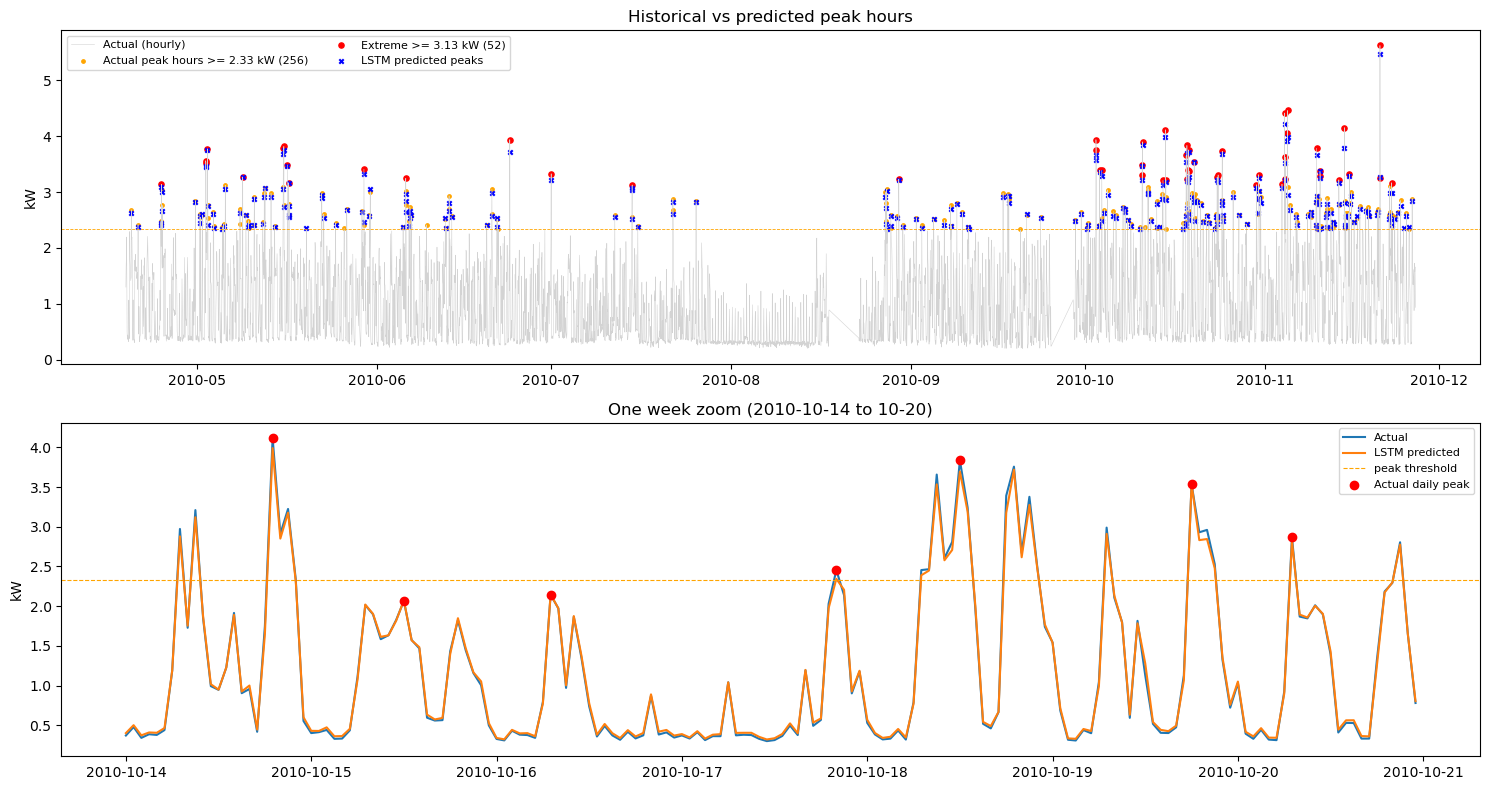

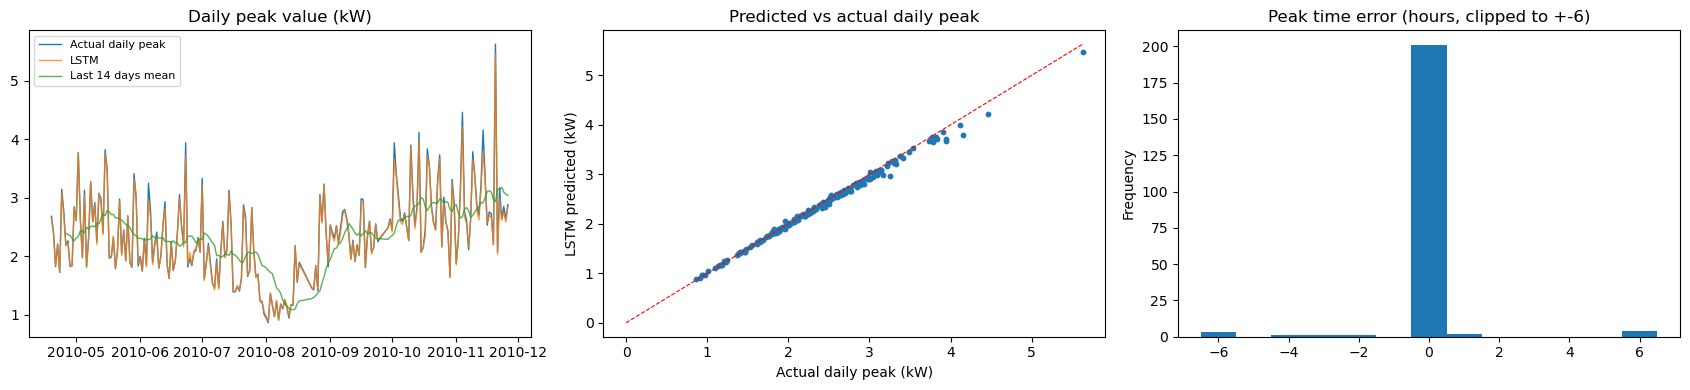

In [16]:
os.makedirs("../reports/figures", exist_ok=True)

lstm, xg = "Tuned LSTM (G4)", "XGBoost (G3)"
thr95, thr99 = ref.quantile(0.95), ref.quantile(0.99)

fig, ax = plt.subplots(2, 1, figsize=(15, 8))
ax[0].plot(ref.index, ref, lw=0.4, color="lightgray", label="Actual (hourly)")
pk, ex = ref[ref >= thr95], ref[ref >= thr99]
ax[0].scatter(pk.index, pk, s=6, color="orange", label=f"Actual peak hours >= {thr95:.2f} kW ({len(pk)})")
ax[0].scatter(ex.index, ex, s=14, color="red", label=f"Extreme >= {thr99:.2f} kW ({len(ex)})")
pp = pred.loc[pred[lstm] >= thr95, lstm]
ax[0].scatter(pp.index, pp, s=10, marker="x", color="blue", label="LSTM predicted peaks")
ax[0].axhline(thr95, color="orange", lw=0.6, ls="--")
ax[0].set_title("Historical vs predicted peak hours"); ax[0].set_ylabel("kW"); ax[0].legend(loc="upper left", ncol=2, fontsize=8)

w = slice("2010-10-14", "2010-10-20")
ax[1].plot(ref.loc[w].index, ref.loc[w], label="Actual")
ax[1].plot(pred.loc[w].index, pred.loc[w, lstm], label="LSTM predicted")
ax[1].axhline(thr95, color="orange", ls="--", lw=0.8, label="peak threshold")
dd = act_d.loc["2010-10-14":"2010-10-20"]
ax[1].scatter(dd["peak_time"], dd["peak_kw"], color="red", zorder=3, label="Actual daily peak")
ax[1].set_title("One week zoom (2010-10-14 to 10-20)"); ax[1].set_ylabel("kW"); ax[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig("../reports/figures/peak_hours_and_week_zoom.png", dpi=150)
plt.show()

pr_l = daily_peak(pred[lstm]).loc[hist.index]
fig, ax = plt.subplots(1, 3, figsize=(17, 4))
ax[0].plot(hist.index, hist["peak_kw"], label="Actual daily peak", lw=1)
ax[0].plot(hist.index, pr_l["peak_kw"], label="LSTM", lw=1, alpha=0.8)
ax[0].plot(hist.index, val14, label="Last 14 days mean", lw=1, alpha=0.8)
ax[0].set_title("Daily peak value (kW)"); ax[0].legend(fontsize=8)

ax[1].scatter(hist["peak_kw"], pr_l["peak_kw"], s=10)
mx = max(hist["peak_kw"].max(), pr_l["peak_kw"].max())
ax[1].plot([0, mx], [0, mx], "r--", lw=0.8)
ax[1].set_xlabel("Actual daily peak (kW)"); ax[1].set_ylabel("LSTM predicted (kW)"); ax[1].set_title("Predicted vs actual daily peak")

err_h = (pr_l["peak_time"] - hist["peak_time"]).dt.total_seconds() / 3600
err_h.clip(-6, 6).plot.hist(bins=np.arange(-6.5, 7.5, 1), ax=ax[2], title="Peak time error (hours, clipped to +-6)")
plt.tight_layout()
plt.savefig("../reports/figures/peak_daily_evaluation.png", dpi=150)
plt.show()

## 9. Save results
`peak_predictions.csv` has one row per day, `peak_predictions_hourly.csv` one row per hour.

In [17]:
thr_high, thr_peak, thr_ext = ref.quantile(0.75), ref.quantile(0.95), ref.quantile(0.99)
print(f"thresholds (kW): high demand {thr_high:.3f} | peak {thr_peak:.3f} | extreme {thr_ext:.3f}")

pl = daily_peak(pred[lstm]).loc[hist.index]
px = daily_peak(pred[xg]).loc[hist.index]

daily_out = pd.DataFrame(index=hist.index)
daily_out.index.name = "Date"
daily_out["actual_peak_kw"] = hist["peak_kw"]
daily_out["actual_peak_time"] = hist["peak_time"]
daily_out["actual_peak_period"] = hist["peak_period"]
daily_out["pred_peak_kw"] = pl["peak_kw"]                 # main: Tuned LSTM (Group 4), forecast-based
daily_out["pred_peak_time"] = pl["peak_time"]
daily_out["pred_peak_period"] = pl["peak_time"].dt.hour.map(period)
daily_out["peak_error_kw"] = daily_out["pred_peak_kw"] - daily_out["actual_peak_kw"]
daily_out["timing_error_hours"] = (daily_out["pred_peak_time"] - daily_out["actual_peak_time"]).dt.total_seconds() / 3600
daily_out["actual_extreme_day"] = daily_out["actual_peak_kw"] >= thr_ext
daily_out["pred_extreme_day"] = daily_out["pred_peak_kw"] >= thr_ext
daily_out["xgb_peak_kw"] = px["peak_kw"]                  # comparison only
daily_out["xgb_peak_time"] = px["peak_time"]
daily_out["dayahead_peak_kw"] = val14                     # mean of previous 14 daily peaks
daily_out["dayahead_peak_hour"] = hr14                    # most common peak hour, previous 14 days

hourly_out = pd.DataFrame({"Actual": ref, "Predicted_LSTM": pred[lstm], "Predicted_XGBoost": pred[xg]})
hourly_out.index.name = "Datetime"
hourly_out["actual_high_demand"] = hourly_out["Actual"] >= thr_high
hourly_out["actual_peak"] = hourly_out["Actual"] >= thr_peak
hourly_out["actual_extreme_peak"] = hourly_out["Actual"] >= thr_ext
hourly_out["pred_peak_lstm"] = hourly_out["Predicted_LSTM"] >= thr_peak
hourly_out["pred_peak_xgboost"] = hourly_out["Predicted_XGBoost"] >= thr_peak

daily_out.to_csv("../reports/peak_predictions.csv")
hourly_out.to_csv("../reports/peak_predictions_hourly.csv")
comparison.round(4).to_csv("../reports/peak_approach_comparison.csv", index=False)
print(daily_out.shape, hourly_out.shape)
daily_out.head()

thresholds (kW): high demand 1.432 | peak 2.330 | extreme 3.128
(213, 14) (5120, 8)


,actual_peak_kw,actual_peak_time,actual_peak_period,pred_peak_kw,pred_peak_time,pred_peak_period,peak_error_kw,timing_error_hours,actual_extreme_day,pred_extreme_day,xgb_peak_kw,xgb_peak_time,dayahead_peak_kw,dayahead_peak_hour
Date,,,,,,,,,,,,,,
2010-04-19,2.682733,2010-04-19 17:00:00,other,2.627612,2010-04-19 17:00:00,other,-0.055122,0.0,False,False,2.668477,2010-04-19 17:00:00,NaN,NaN
2010-04-20,2.415400,2010-04-20 20:00:00,evening (18-22),2.378831,2010-04-20 20:00:00,evening (18-22),-0.036569,0.0,False,False,2.400859,2010-04-20 20:00:00,NaN,NaN
2010-04-21,1.823300,2010-04-21 23:00:00,other,1.841132,2010-04-21 23:00:00,other,0.017832,0.0,False,False,1.793217,2010-04-21 23:00:00,NaN,NaN
2010-04-22,2.207300,2010-04-22 12:00:00,other,2.167376,2010-04-22 12:00:00,other,-0.039924,0.0,False,False,2.197233,2010-04-22 12:00:00,NaN,NaN
2010-04-23,1.722433,2010-04-23 08:00:00,morning (06-09),1.723629,2010-04-23 08:00:00,morning (06-09),0.001195,0.0,False,False,1.717679,2010-04-23 08:00:00,NaN,NaN


### Save peak-hour metrics and the day-ahead comparison

In [18]:
thr = ref.quantile(0.95)
y_true = ref >= thr
rows = []
for n in pred.columns:
    yp = pred[n] >= thr
    e = (pred[n] - ref)[y_true]
    rows.append({"model": n, "threshold_kW": thr, "actual_peak_hours": int(y_true.sum()),
                 "flagged": int(yp.sum()),
                 "precision": precision_score(y_true, yp, zero_division=0),
                 "recall": recall_score(y_true, yp, zero_division=0),
                 "F1": f1_score(y_true, yp, zero_division=0),
                 "MAE_on_peak_hours_kW": e.abs().mean(),
                 "RMSE_on_peak_hours_kW": (e ** 2).mean() ** 0.5,
                 "bias_on_peak_hours_kW": e.mean()})
peak_hour_metrics = pd.DataFrame(rows).round(4)
peak_hour_metrics.to_csv("../reports/peak_hour_metrics.csv", index=False)
day_ahead.round(4).to_csv("../reports/peak_dayahead_comparison.csv", index=False)
peak_hour_metrics

,model,threshold_kW,actual_peak_hours,flagged,precision,recall,F1,MAE_on_peak_hours_kW,RMSE_on_peak_hours_kW,bias_on_peak_hours_kW
0,Tuned LSTM (G4),2.3304,256,252,0.9881,0.9727,0.9803,0.0567,0.0800,-0.0507
1,XGBoost (G3),2.3304,256,253,0.9881,0.9766,0.9823,0.0220,0.0278,-0.0035
2,ARIMA (G3),2.3304,256,0,0.0000,0.0000,0.0000,1.8522,1.9112,-1.8522
